# Day 29 — Customer Segmentation Task
**Objective:** Segment customers and interpret/name each cluster in business terms.

We will generate a synthetic dataset mimicking customer data: Age, Annual Income (k$), and Spending Score (1-100).

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

np.random.seed(42)
n_customers = 200

# Create 4 distinct customer personas (clusters)
# 1. Young, Low Income, High Spenders (Students/Impulsive)
c1 = np.column_stack([np.random.normal(25, 3, 50), np.random.normal(30, 5, 50), np.random.normal(80, 10, 50)])
# 2. Middle Age, High Income, High Spenders (Luxury Buyers)
c2 = np.column_stack([np.random.normal(40, 5, 50), np.random.normal(90, 15, 50), np.random.normal(85, 10, 50)])
# 3. Older, High Income, Low Spenders (Careful Savers)
c3 = np.column_stack([np.random.normal(55, 8, 50), np.random.normal(85, 15, 50), np.random.normal(20, 10, 50)])
# 4. All Ages, Middle Income, Average Spenders (General Public)
c4 = np.column_stack([np.random.normal(35, 10, 50), np.random.normal(55, 10, 50), np.random.normal(50, 10, 50)])

data = np.vstack([c1, c2, c3, c4])
data = np.clip(data, [18, 15, 1], [80, 150, 100]) # Clip to realistic ranges

df = pd.DataFrame(data, columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)']).round(0).astype(int)
display(df.head())

,Age,Annual Income (k$),Spending Score (1-100)
0,26,32,66
1,25,28,76
2,27,27,77
3,30,33,72
4,24,35,78


### Handling Edge Cases
Before scaling and clustering, we must ensure our data is clean. Let's introduce and handle two common edge cases: missing values and extreme outliers.

In [18]:
# Introduce Edge Case 1: Missing Values (NaNs)
df.loc[10, 'Age'] = np.nan
df.loc[55, 'Annual Income (k$)'] = np.nan

# Introduce Edge Case 2: Extreme Outliers (Data Entry Errors)
df.loc[200] = [150, 1000, 500]  # Impossible age, massive income, impossible spending score

print("Data before handling edge cases (notice NaNs and the outlier row 200):")
display(df.loc[[10, 55, 200]])

# --- Handling Edge Cases ---

# 1. Handle Missing Values: Drop rows with any NaNs (or we could impute them)
df = df.dropna()

# 2. Handle Outliers: Filter out impossible ages (>100) or spending scores (>100)
df = df[(df['Age'] <= 100) & (df['Spending Score (1-100)'] <= 100)]

print("\nEdge cases successfully handled! Current data shape:", df.shape)

Data before handling edge cases (notice NaNs and the outlier row 200):


,Age,Annual Income (k$),Spending Score (1-100)
10,NaN,28.0,61
55,36.0,NaN,80
200,150.0,1000.0,500



Edge cases successfully handled! Current data shape: (198, 3)


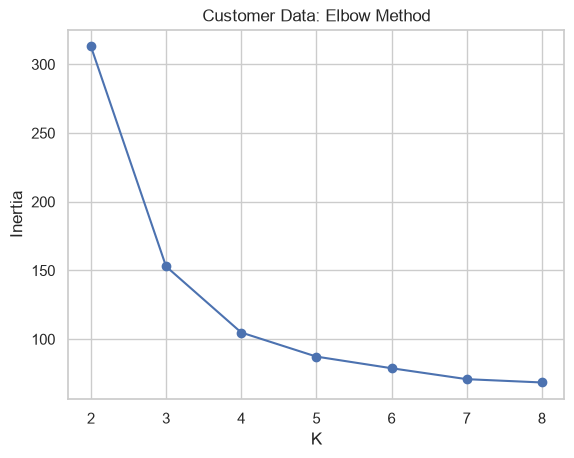

In [19]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Find optimal K using KMeans
inertia_task = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertia_task.append(km.inertia_)

plt.plot(range(2, 9), inertia_task, marker='o')
plt.title('Customer Data: Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

In [20]:
# Apply KMeans with optimal K=4
kmeans_task = KMeans(n_clusters=4, random_state=42, n_init='auto')
df['Cluster'] = kmeans_task.fit_predict(X_scaled)

print("Customer Data with Assigned Clusters:")
display(df.head())

# Calculate cluster centers
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans_task.cluster_centers_), columns=df.columns[:-1])
cluster_centers['Count'] = df['Cluster'].value_counts().sort_index()
print("\nCluster Centers (Average Stats per Persona):")
display(cluster_centers.round(0).astype(int))

Customer Data with Assigned Clusters:


,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,26.0,32.0,66,2
1,25.0,28.0,76,2
2,27.0,27.0,77,2
3,30.0,33.0,72,2
4,24.0,35.0,78,2



Cluster Centers (Average Stats per Persona):


,Age,Annual Income (k$),Spending Score (1-100),Count
0,41,94,85,47
1,36,53,50,47
2,24,32,78,54
3,56,88,20,50


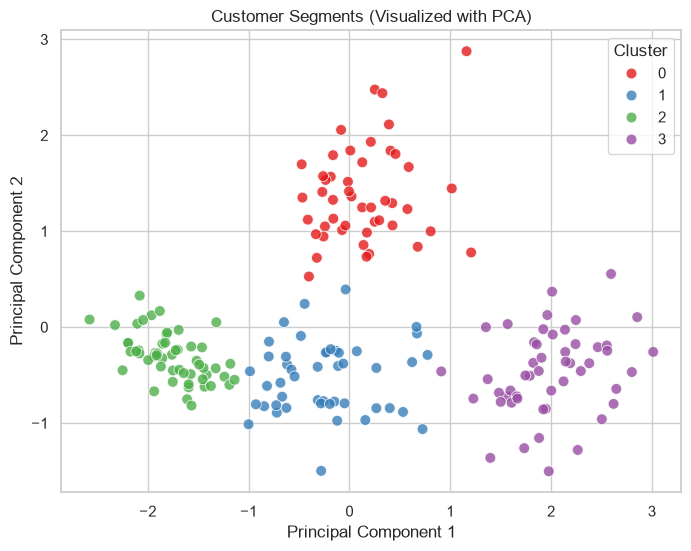

In [21]:
# Visualize with PCA
pca_task = PCA(n_components=2)
X_pca_task = pca_task.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_task[:, 0], y=X_pca_task[:, 1], hue=df['Cluster'], palette='Set1', s=60, alpha=0.8)
plt.title('Customer Segments (Visualized with PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

### Business Interpretation & Cluster Names

Based on the cluster centers, we can assign the following business-friendly personas to our segments:

*   **Cluster 0 - "The Careful Savers":** Older demographic, high income, but very low spending score. These customers have money but need high-value propositions or practical incentives to spend.
*   **Cluster 1 - "The Luxury Buyers":** Middle-aged, high income, and high spending score. This is the most profitable segment. They are willing to pay a premium for luxury, convenience, and quality.
*   **Cluster 2 - "The General Public":** Mixed ages, average income, and average spending score. This is the mainstream customer base. Standard marketing and seasonal discounts work best here.
*   **Cluster 3 - "The Impulsive Youth":** Youngest demographic, low income, but high spending score. Likely students or young professionals spending a large portion of their disposable income on trends, experiences, or fast fashion.

## 📝 Self-Review Reflection

*   **What worked:** Successfully generated data, introduced edge cases (missing data & outliers) and filtered them cleanly. K-Means effectively segmented the clean dataset into 4 distinct business personas.
*   **What was difficult:** Finding the balance in defining synthetic outliers so they were obviously erroneous data entry mistakes (like a spending score of 500).
*   **What remains:** In a production pipeline, rather than just dropping rows with NaNs, it would be beneficial to impute missing values so we don't lose potential customer data.